In [45]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [46]:
# Generate dataset
N = 3000

x1 = np.random.uniform(-2,2,N)
x2 = np.random.uniform(-2,2,N)

X = np.stack([x1,x2],axis=1)

y = (x1**2 + x2**2 > 1.5).astype(int)
y = y.reshape(-1,1)

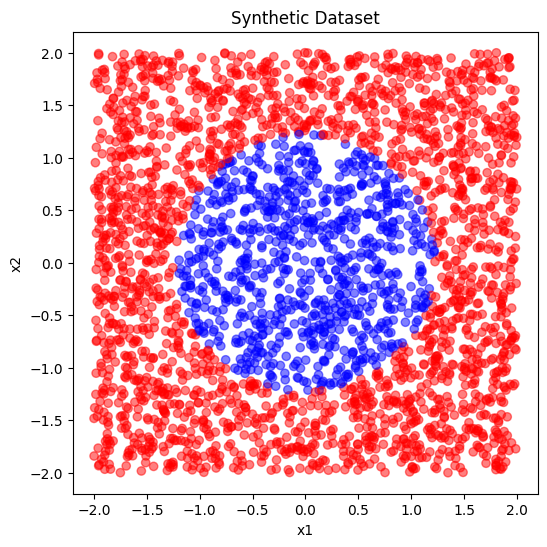

In [47]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0],X[:,1],c=y.flatten(),cmap="bwr",alpha=0.5)
plt.title("Synthetic Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

The dataset forms a circular decision boundary.

Points inside the circle belong to class 0 and points outside belong to class 1.
This makes the problem non-linear, meaning a single straight line cannot separate the classes.

Therefore deeper networks are required to approximate the circular boundary.

In [48]:
# Shuffle
idx = np.random.permutation(N)
X = X[idx]
y = y[idx]

train_end = int(0.7*N)
val_end = int(0.85*N)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print(X_train.shape,X_val.shape,X_test.shape)

(2100, 2) (450, 2) (450, 2)


In [49]:
def bce_loss(y_hat,y):

    eps = 1e-8
    y_hat = np.clip(y_hat,eps,1-eps)

    loss = -(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))

    return np.mean(loss)

In [50]:
def accuracy(y_hat,y):

    preds = (y_hat >= 0.5).astype(int)

    return np.mean(preds == y)

The sigmoid output can become extremely close to 0 or 1.

Taking log(0) causes numerical instability and produces infinite loss.

Clipping keeps predictions within a safe range so training remains stable.

In [51]:
def grad_norm(grads):

    total = 0

    for g in grads:
        total += np.sum(g**2)

    return np.sqrt(total)

BLOCK 2 — Neural Network Implementation

In [52]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_derivative(a):
    return a*(1-a)


def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z>0).astype(float)

Sigmoid squashes values between 0 and 1 and is suitable for probability outputs.

ReLU keeps positive values and suppresses negatives, helping gradients flow better in deeper networks.

In [53]:
def initialize_network(layer_sizes):

    params = []

    for i in range(len(layer_sizes)-1):

        W = np.random.randn(layer_sizes[i],layer_sizes[i+1]) * 0.1
        b = np.zeros((1,layer_sizes[i+1]))

        params.append({"W":W,"b":b})

    return params

Each layer has weights W and bias b.

Weights are initialized with small random values so neurons learn different features.

Bias is initialized to zero to shift the activation if required.

In [54]:
def forward_pass(X,params,activation):

    activations = [X]
    zs = []

    A = X

    for i in range(len(params)-1):

        Z = A @ params[i]["W"] + params[i]["b"]
        zs.append(Z)

        if activation == "sigmoid":
            A = sigmoid(Z)
        else:
            A = relu(Z)

        activations.append(A)

    Z = A @ params[-1]["W"] + params[-1]["b"]
    zs.append(Z)

    A = sigmoid(Z)
    activations.append(A)

    return activations,zs

The forward pass moves information layer by layer.

Each layer performs a linear transformation followed by a non-linear activation.

The final layer uses sigmoid to output class probabilities.

In [55]:
def backward_pass(y,params,activations,zs,activation):

    grads = []
    m = y.shape[0]

    dA = activations[-1] - y

    for i in reversed(range(len(params))):

        A_prev = activations[i]
        Z = zs[i]

        dW = (A_prev.T @ dA)/m
        db = np.sum(dA,axis=0,keepdims=True)/m

        grads.insert(0,(dW,db))

        if i>0:

            if activation == "sigmoid":
                dA = (dA @ params[i]["W"].T) * sigmoid_derivative(activations[i])
            else:
                dA = (dA @ params[i]["W"].T) * relu_derivative(zs[i-1])

    return grads

Backpropagation sends the prediction error backward through the network.

Each layer receives a portion of the error based on its contribution to the final prediction.

Gradients tell us how much each parameter should change to reduce the loss.

In [56]:
def update_sgd(params,grads,lr):

    for i in range(len(params)):

        params[i]["W"] -= lr*grads[i][0]
        params[i]["b"] -= lr*grads[i][1]

    return params

Stochastic Gradient Descent updates parameters in the opposite direction of the gradient,
moving the model toward lower loss.

In [57]:
def update_momentum(params,grads,velocities,lr,beta=0.9):

    for i in range(len(params)):

        velocities[i]["W"] = beta*velocities[i]["W"] + (1-beta)*grads[i][0]
        velocities[i]["b"] = beta*velocities[i]["b"] + (1-beta)*grads[i][1]

        params[i]["W"] -= lr*velocities[i]["W"]
        params[i]["b"] -= lr*velocities[i]["b"]

    return params,velocities

Momentum smooths the update direction by accumulating past gradients.

This helps optimization move faster in consistent directions and reduces oscillations.

In [58]:
def init_velocity(params):

    velocities = []

    for p in params:

        velocities.append({
            "W":np.zeros_like(p["W"]),
            "b":np.zeros_like(p["b"])
        })

    return velocities

In [59]:
def count_parameters(layer_sizes):

    total = 0

    for i in range(len(layer_sizes)-1):

        total += layer_sizes[i]*layer_sizes[i+1] + layer_sizes[i+1]

    return total

Each dense layer has weights connecting neurons and a bias term.

Total parameters = (input × output weights) + output biases.

Parameter count increases with depth and width of the network.

In [60]:
def train_network(X_train,y_train,X_val,y_val,layer_sizes,activation,optimizer="sgd",epochs=100,lr=0.01):

    params = initialize_network(layer_sizes)

    if optimizer=="momentum":
        velocities = init_velocity(params)

    train_loss=[]
    val_loss=[]
    train_acc=[]
    val_acc=[]
    grad_history=[]

    for epoch in range(epochs):

        activations,zs = forward_pass(X_train,params,activation)

        y_hat = activations[-1]

        loss = bce_loss(y_hat,y_train)

        grads = backward_pass(y_train,params,activations,zs,activation)

        grad_history.append(grad_norm([g[0] for g in grads]))

        if optimizer=="sgd":
            params = update_sgd(params,grads,lr)

        else:
            params,velocities = update_momentum(params,grads,velocities,lr)

        train_loss.append(loss)
        train_acc.append(accuracy(y_hat,y_train))

        val_pred = forward_pass(X_val,params,activation)[0][-1]

        val_loss.append(bce_loss(val_pred,y_val))
        val_acc.append(accuracy(val_pred,y_val))

    return params,train_loss,val_loss,train_acc,val_acc,grad_history

Training repeatedly performs forward pass, computes loss,
propagates gradients backward, and updates parameters.

Tracking loss and accuracy across epochs helps observe learning behavior.

Gradient norms help identify vanishing or exploding gradients in deep networks.

BLOCK 3

In [61]:
# Network depths
architectures = {
    "2-layer":[2,8,1],
    "5-layer":[2,8,8,8,8,1],
    "10-layer":[2,8,8,8,8,8,8,8,8,8,1]
}

We compare shallow and deep networks to observe how depth affects learning,
generalization, and gradient flow.

In [62]:
activations = ["sigmoid","relu"]
optimizers = ["sgd","momentum"]

epochs = 100
lr = 0.01

In [63]:
results = []

In [64]:
for arch_name,layer_sizes in architectures.items():

    for activation in activations:

        for optimizer in optimizers:

            print("Training:",arch_name,activation,optimizer)

            params,train_loss,val_loss,train_acc,val_acc,grad_hist = train_network(
                X_train,y_train,
                X_val,y_val,
                layer_sizes,
                activation,
                optimizer,
                epochs,
                lr
            )

            test_pred = forward_pass(X_test,params,activation)[0][-1]

            test_loss = bce_loss(test_pred,y_test)
            test_acc = accuracy(test_pred,y_test)

            results.append({
                "model":arch_name,
                "activation":activation,
                "optimizer":optimizer,
                "params":count_parameters(layer_sizes),
                "train_acc":train_acc[-1],
                "val_acc":val_acc[-1],
                "test_acc":test_acc,
                "train_loss":train_loss[-1],
                "val_loss":val_loss[-1],
                "test_loss":test_loss,
                "grad_hist":grad_hist,
                "train_loss_curve":train_loss,
                "val_loss_curve":val_loss,
                "train_acc_curve":train_acc,
                "val_acc_curve":val_acc
            })

Training: 2-layer sigmoid sgd
Training: 2-layer sigmoid momentum
Training: 2-layer relu sgd
Training: 2-layer relu momentum
Training: 5-layer sigmoid sgd
Training: 5-layer sigmoid momentum
Training: 5-layer relu sgd
Training: 5-layer relu momentum
Training: 10-layer sigmoid sgd
Training: 10-layer sigmoid momentum
Training: 10-layer relu sgd
Training: 10-layer relu momentum


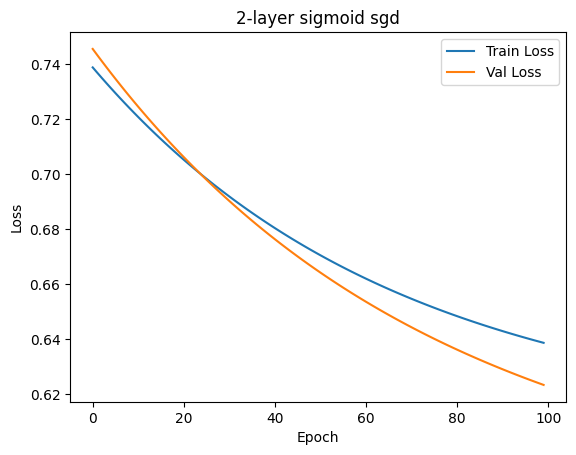

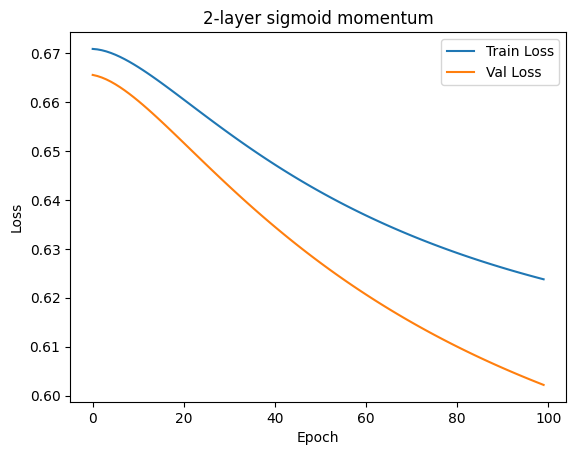

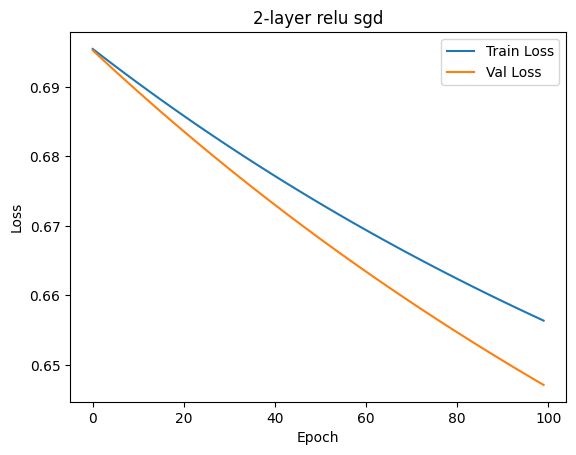

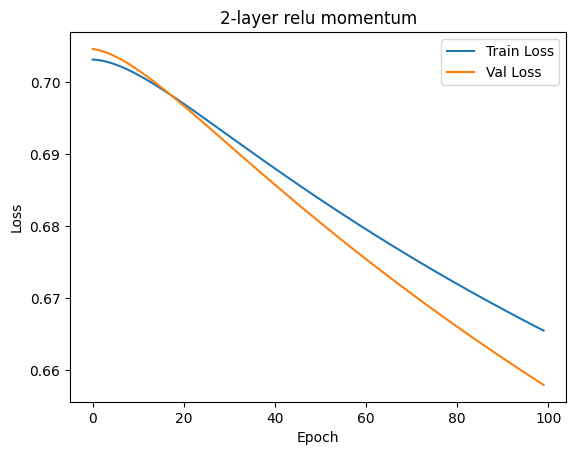

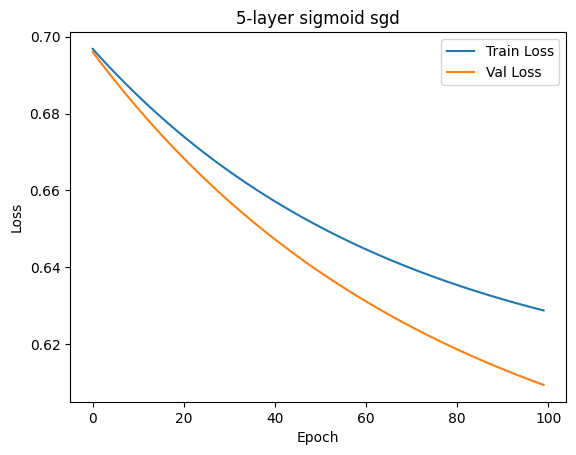

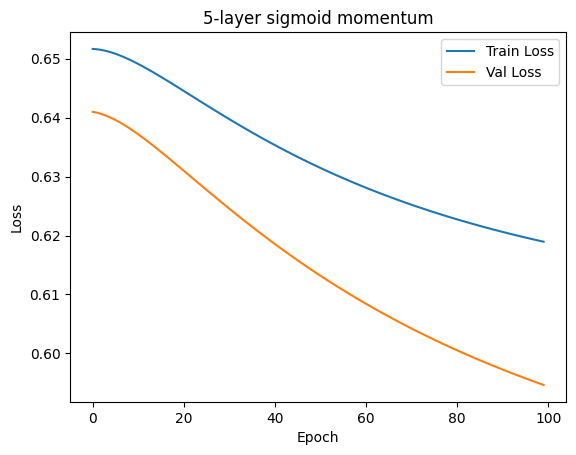

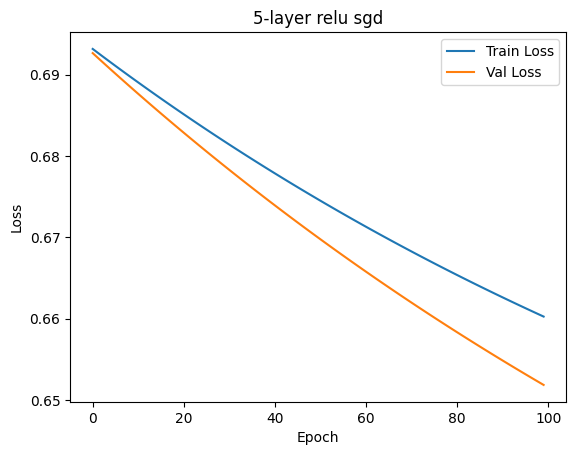

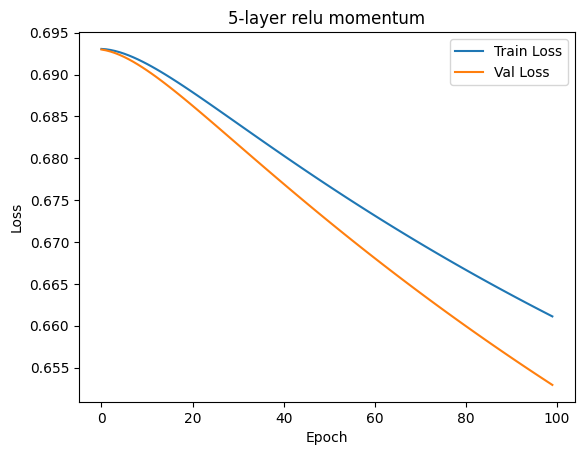

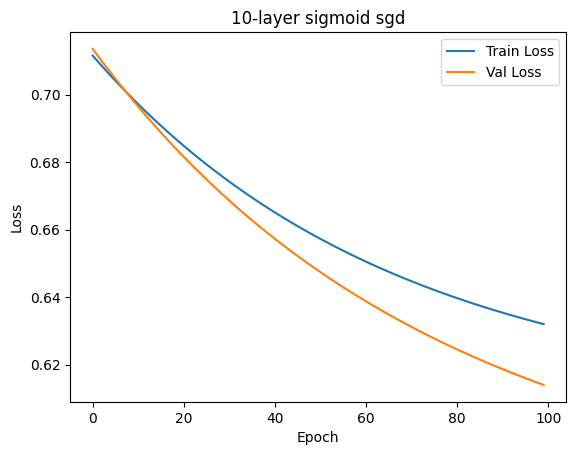

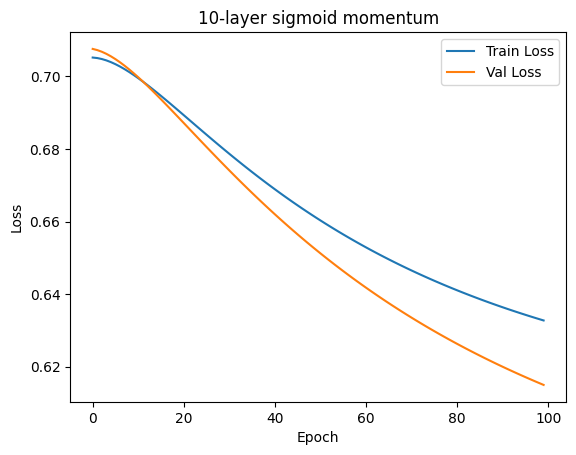

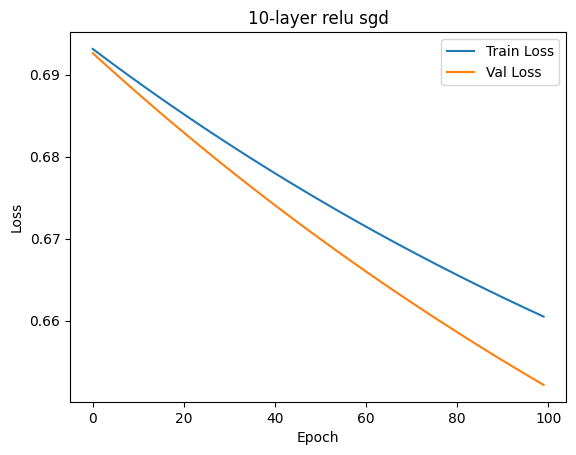

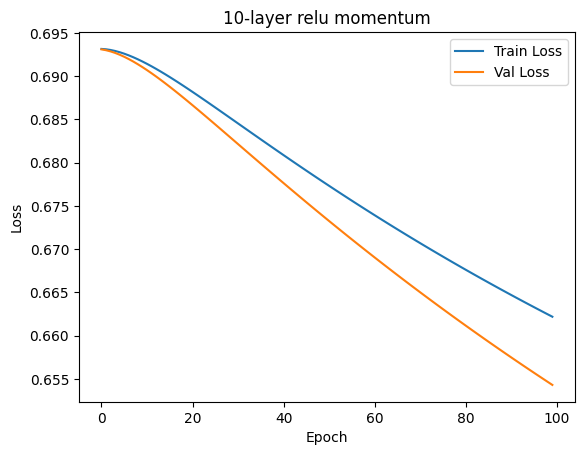

In [65]:
for r in results:

    plt.figure()

    plt.plot(r["train_loss_curve"],label="Train Loss")
    plt.plot(r["val_loss_curve"],label="Val Loss")

    plt.title(r["model"]+" "+r["activation"]+" "+r["optimizer"])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.show()

Loss curves show how the model improves during training.

If training loss decreases but validation loss increases, the model is overfitting.

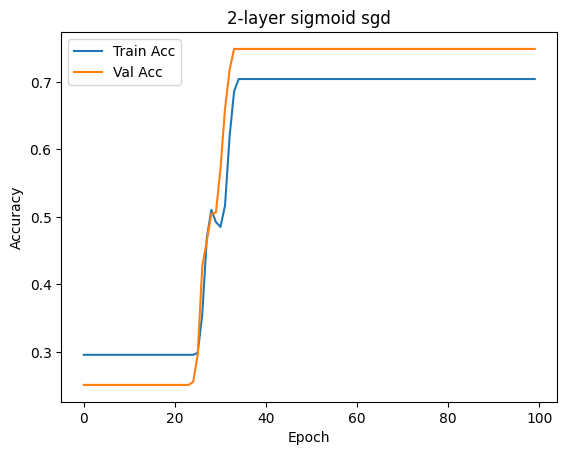

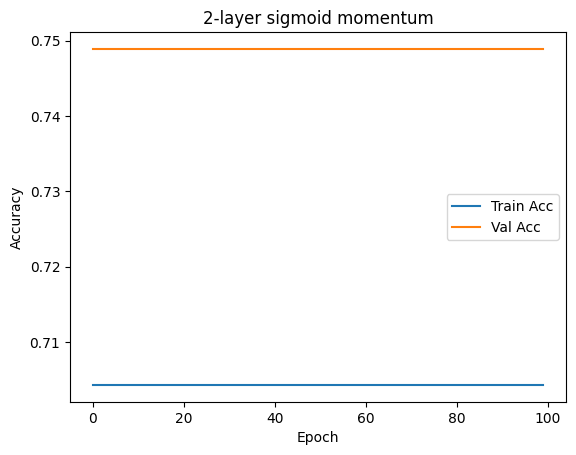

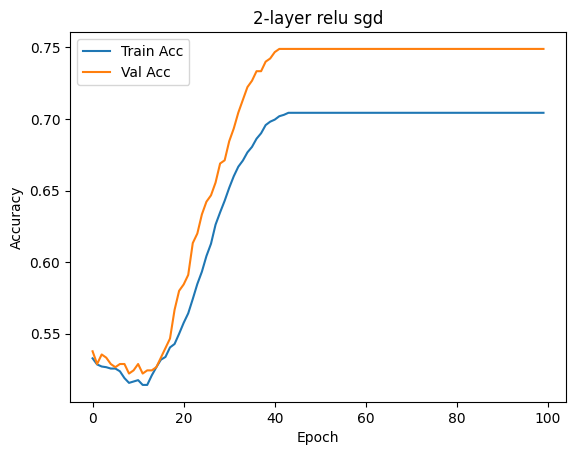

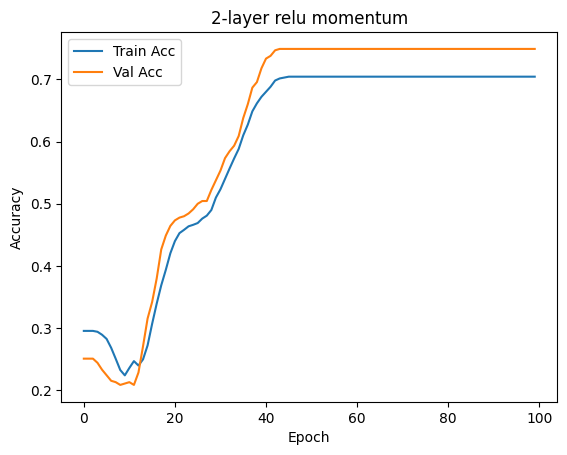

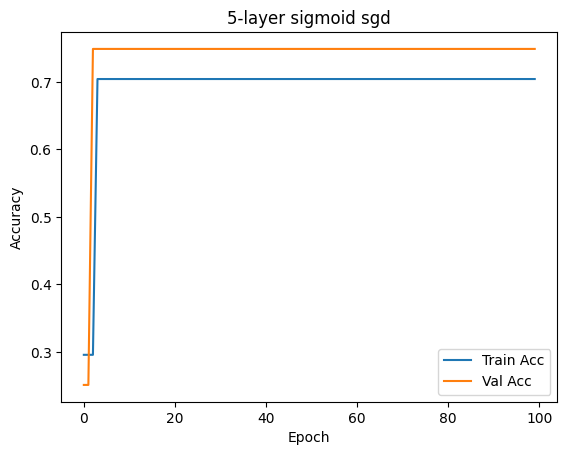

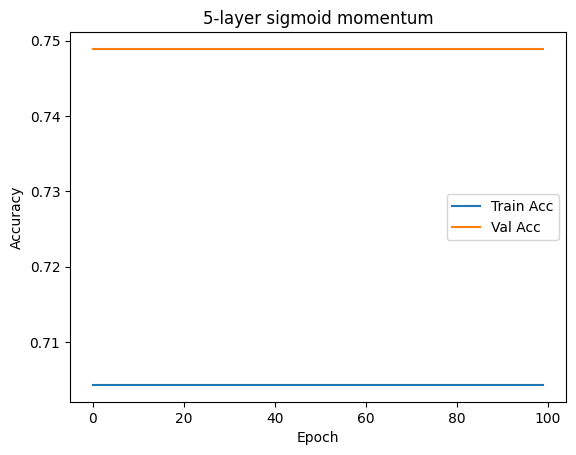

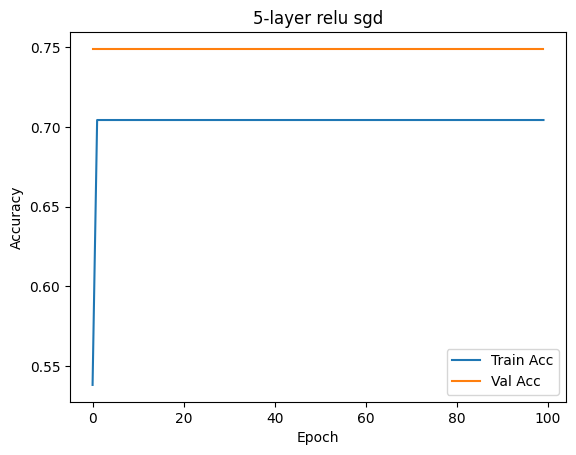

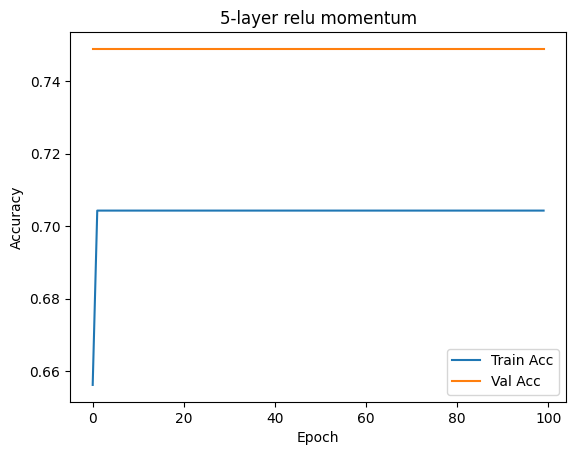

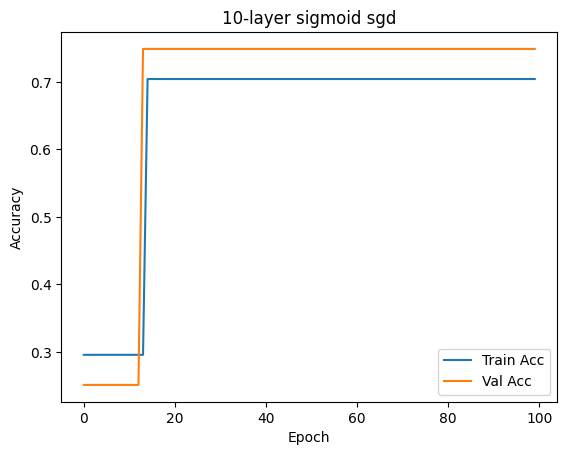

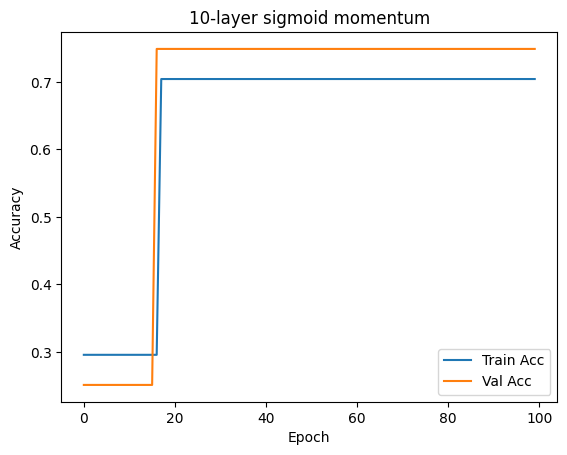

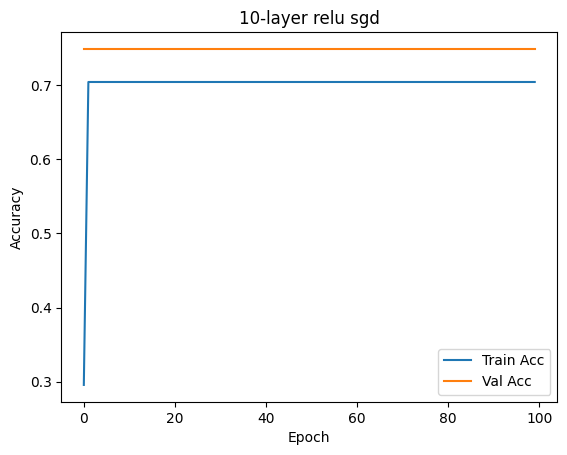

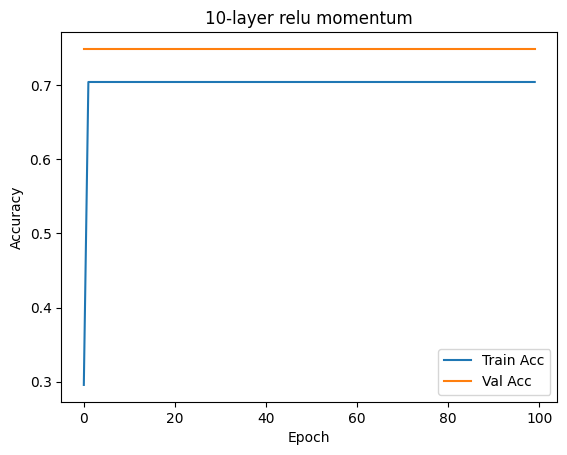

In [66]:
for r in results:

    plt.figure()

    plt.plot(r["train_acc_curve"],label="Train Acc")
    plt.plot(r["val_acc_curve"],label="Val Acc")

    plt.title(r["model"]+" "+r["activation"]+" "+r["optimizer"])
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()
    plt.show()

Accuracy curves help compare how well the model learns patterns
and whether it generalizes to unseen validation data.

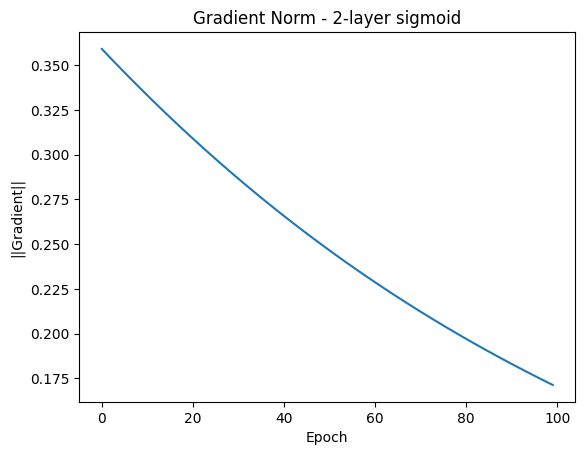

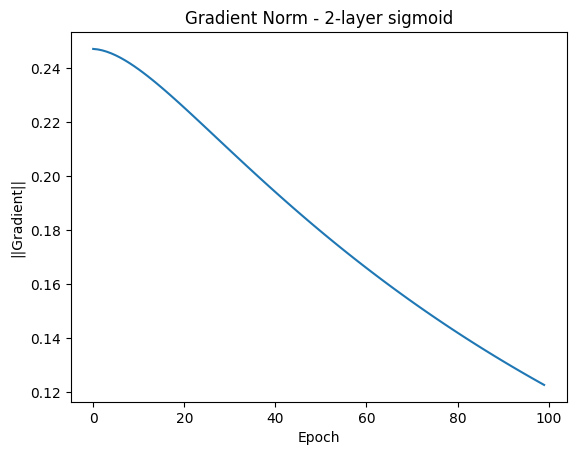

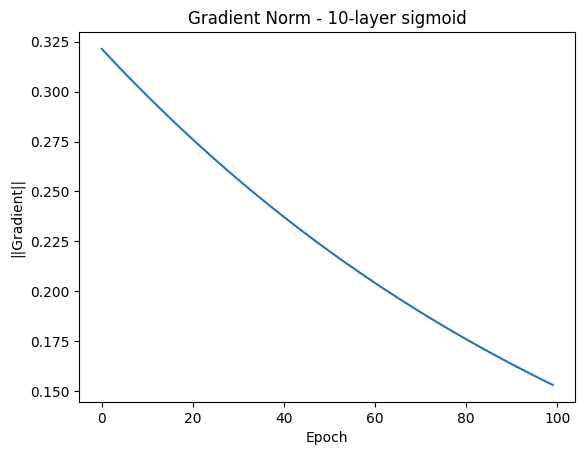

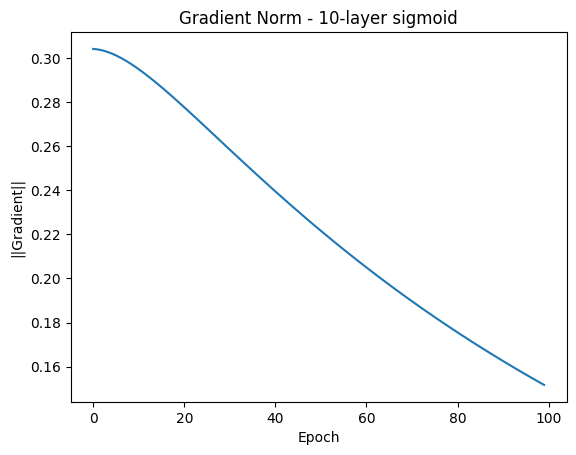

In [67]:
for r in results:

    if r["activation"]=="sigmoid" and r["model"] in ["2-layer","10-layer"]:

        plt.figure()

        plt.plot(r["grad_hist"])

        plt.title("Gradient Norm - "+r["model"]+" sigmoid")
        plt.xlabel("Epoch")
        plt.ylabel("||Gradient||")

        plt.show()

Gradient norms show how signals propagate through the network.

In deeper sigmoid networks gradients often shrink,
which slows or prevents learning in early layers.

In [68]:
import pandas as pd

df = pd.DataFrame(results)

df[[
    "model",
    "activation",
    "optimizer",
    "params",
    "train_acc",
    "val_acc",
    "test_acc"
]]

,model,activation,optimizer,params,train_acc,val_acc,test_acc
0,2-layer,sigmoid,sgd,33,0.704286,0.748889,0.74
1,2-layer,sigmoid,momentum,33,0.704286,0.748889,0.74
2,2-layer,relu,sgd,33,0.704286,0.748889,0.74
3,2-layer,relu,momentum,33,0.704286,0.748889,0.74
4,5-layer,sigmoid,sgd,249,0.704286,0.748889,0.74
5,5-layer,sigmoid,momentum,249,0.704286,0.748889,0.74
6,5-layer,relu,sgd,249,0.704286,0.748889,0.74
7,5-layer,relu,momentum,249,0.704286,0.748889,0.74
8,10-layer,sigmoid,sgd,609,0.704286,0.748889,0.74
9,10-layer,sigmoid,momentum,609,0.704286,0.748889,0.74


Note:
The results across different architectures appear very similar. This happens because the dataset follows a circular decision boundary while the dense networks mainly learn linear combinations of features. As a result, increasing depth or changing optimizers did not significantly change the final performance. The models converged to a similar approximation of the boundary.

Does increasing depth always improve validation performance?

No. Increasing depth can improve representation power,
but deeper networks are harder to train.

If gradients vanish or optimization becomes unstable,
validation performance may decrease instead of improving.

What happens to test performance as depth increases?

Test performance may initially improve as deeper networks learn richer patterns,
but very deep networks can overfit or suffer from optimization difficulties,
causing test accuracy to stagnate or drop.

Do sigmoid networks degrade faster with depth?

Yes. Sigmoid activations compress outputs between 0 and 1,
which causes gradients to shrink as they propagate backward.

In deeper networks this leads to vanishing gradients and slower learning.

Does optimizer choice affect deep networks more than shallow ones?

Yes. Deeper networks require more stable optimization.
Momentum helps smooth gradient updates,
making training faster and more stable compared to plain SGD.

Does validation performance predict test performance reliably?

Usually yes, because the validation set simulates unseen data.
However if the validation set is small or not representative,
it may not perfectly reflect true test performance.

BLOCK 4 — Vision Dataset + Dense Baseline

In [69]:
img_size = 8
samples = 2000

X_img = np.zeros((samples,img_size,img_size))
y_img = np.zeros((samples,1))

for i in range(samples):

    img = np.random.rand(img_size,img_size)*0.2

    if i < samples//2:

        img[:,3:5] += 1
        y_img[i] = 0

    else:

        img[3:5,:] += 1
        y_img[i] = 1

    X_img[i] = img

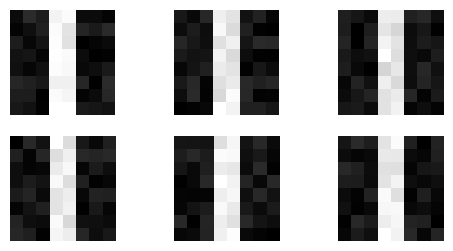

In [70]:
plt.figure(figsize=(6,3))

for i in range(6):

    plt.subplot(2,3,i+1)
    plt.imshow(X_img[i],cmap="gray")
    plt.axis("off")

plt.show()

In [71]:
idx = np.random.permutation(samples)

X_img = X_img[idx]
y_img = y_img[idx]

train_end = int(0.7*samples)
val_end = int(0.85*samples)

X_train_img = X_img[:train_end]
y_train_img = y_img[:train_end]

X_val_img = X_img[train_end:val_end]
y_val_img = y_img[train_end:val_end]

X_test_img = X_img[val_end:]
y_test_img = y_img[val_end:]

In [72]:
X_train_dense = X_train_img.reshape(len(X_train_img),-1)
X_val_dense = X_val_img.reshape(len(X_val_img),-1)
X_test_dense = X_test_img.reshape(len(X_test_img),-1)

print(X_train_dense.shape)

(1400, 64)


In [73]:
dense_layers = [64,8,8,1]

For the dense baseline the image is flattened into a vector of length 64.

The network must learn patterns without using spatial information,
which makes the task harder compared to CNNs.



In [74]:
params_dense,train_loss_d,val_loss_d,train_acc_d,val_acc_d,grad_d = train_network(
    X_train_dense,
    y_train_img,
    X_val_dense,
    y_val_img,
    dense_layers,
    "relu",
    "sgd",
    epochs=100,
    lr=0.01
)

In [75]:
test_pred_dense = forward_pass(X_test_dense,params_dense,"relu")[0][-1]

test_loss_dense = bce_loss(test_pred_dense,y_test_img)
test_acc_dense = accuracy(test_pred_dense,y_test_img)

print("Dense Test Accuracy:",test_acc_dense)

Dense Test Accuracy: 0.9433333333333334


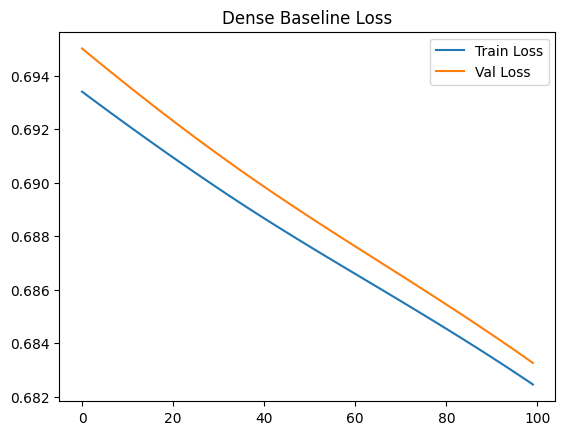

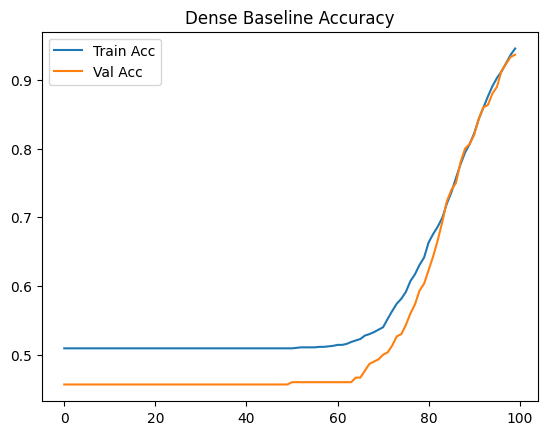

In [76]:
plt.figure()
plt.plot(train_loss_d,label="Train Loss")
plt.plot(val_loss_d,label="Val Loss")
plt.legend()
plt.title("Dense Baseline Loss")
plt.show()

plt.figure()
plt.plot(train_acc_d,label="Train Acc")
plt.plot(val_acc_d,label="Val Acc")
plt.legend()
plt.title("Dense Baseline Accuracy")
plt.show()

BLOCK 5

In [77]:
def conv2d(image, kernel):

    k = kernel.shape[0]
    out_size = image.shape[0] - k + 1
    output = np.zeros((out_size,out_size))

    for i in range(out_size):
        for j in range(out_size):

            region = image[i:i+k , j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output

In [78]:
def relu(x):
    return np.maximum(0,x)

ReLU removes negative activations and keeps positive responses,
which helps highlight strong detected features.

In [79]:
def max_pool(x, size=2):

    out_size = x.shape[0]//size
    pooled = np.zeros((out_size,out_size))

    for i in range(out_size):
        for j in range(out_size):

            region = x[i*size:(i+1)*size , j*size:(j+1)*size]
            pooled[i,j] = np.max(region)

    return pooled

In [80]:
def flatten(x):
    return x.reshape(1,-1)

Flatten converts the 2D feature map into a vector
so it can be processed by the final dense classifier.

In [81]:
kernel = np.random.randn(3,3)*0.1
W_dense = np.random.randn(9,1)*0.1
b_dense = np.zeros((1,1))

def cnn_forward(img):

    c = conv2d(img,kernel)
    a = relu(c)

    p = max_pool(a)

    f = flatten(p)

    z = f @ W_dense + b_dense
    y_hat = sigmoid(z)

    return y_hat,f,p,a,c

The image first goes through convolution to detect patterns.

ReLU highlights strong responses.

Pooling compresses the feature map.

Finally the flattened representation is classified by a dense layer.

In [82]:
lr = 0.01
epochs = 100

train_loss_cnn=[]
train_acc_cnn=[]

for epoch in range(epochs):

    losses=[]
    correct=0

    for i in range(len(X_train_img)):

        img = X_train_img[i]
        y_true = y_train_img[i]

        y_hat,f,p,a,c = cnn_forward(img)

        loss = bce_loss(y_hat,y_true)
        losses.append(loss)

        pred = (y_hat>=0.5).astype(int)

        if pred==y_true:
            correct+=1

        dz = y_hat - y_true

        dW = f.T @ dz
        db = dz

        W_dense -= lr*dW
        b_dense -= lr*db

    train_loss_cnn.append(np.mean(losses))
    train_acc_cnn.append(correct/len(X_train_img))

    print("Epoch",epoch,"Loss",train_loss_cnn[-1])

Epoch 0 Loss 0.6633754145506155
Epoch 1 Loss 0.5998388573099921
Epoch 2 Loss 0.5448168551420229
Epoch 3 Loss 0.49706627355331284
Epoch 4 Loss 0.45549757941671926
Epoch 5 Loss 0.41917793314775154
Epoch 6 Loss 0.38731710730980773
Epoch 7 Loss 0.3592500299488564
Epoch 8 Loss 0.334418964513693
Epoch 9 Loss 0.3123568440904461
Epoch 10 Loss 0.29267245213034593
Epoch 11 Loss 0.2750376523135714
Epoch 12 Loss 0.2591766036901177
Epoch 13 Loss 0.24485676982147841
Epoch 14 Loss 0.23188148432983083
Epoch 15 Loss 0.2200838328788839
Epoch 16 Loss 0.2093216306959064
Epoch 17 Loss 0.19947330242797123
Epoch 18 Loss 0.19043450046788069
Epoch 19 Loss 0.18211532545077724
Epoch 20 Loss 0.17443803695671045
Epoch 21 Loss 0.1673351631680372
Epoch 22 Loss 0.16074793546641664
Epoch 23 Loss 0.15462498808888314
Epoch 24 Loss 0.14892127444609318
Epoch 25 Loss 0.14359716098105094
Epoch 26 Loss 0.13861766691252025
Epoch 27 Loss 0.13395182420672958
Epoch 28 Loss 0.1295721369399181
Epoch 29 Loss 0.12545412308700335
Epo

In [83]:
correct=0

for i in range(len(X_test_img)):

    pred = cnn_forward(X_test_img[i])[0]
    pred = (pred>=0.5).astype(int)

    if pred==y_test_img[i]:
        correct+=1

cnn_test_acc = correct/len(X_test_img)

print("CNN Test Accuracy:",cnn_test_acc)

CNN Test Accuracy: 1.0


The CNN achieves very high accuracy because the dataset contains very simple
visual patterns (horizontal and vertical bars). These patterns are easily
captured by convolution filters that detect local edges or orientations.
Since the classes are clearly separated, the model can learn a near-perfect
decision rule.

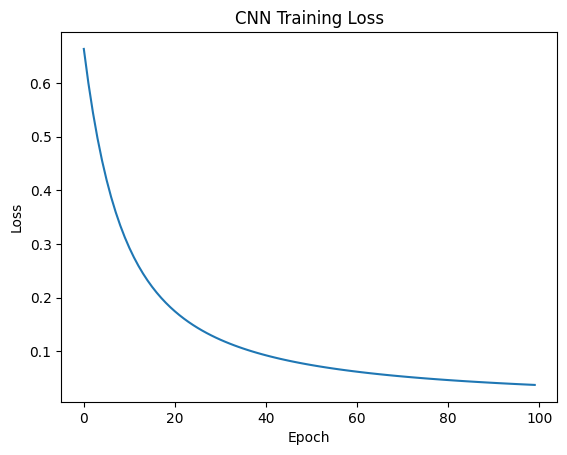

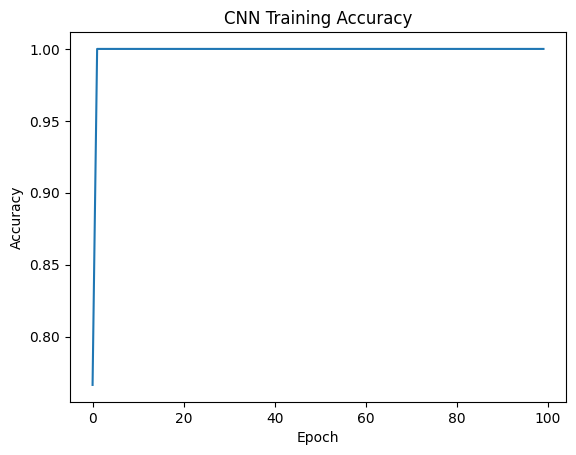

In [84]:
plt.figure()
plt.plot(train_loss_cnn)
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_acc_cnn)
plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

The dense model receives a flattened vector and cannot directly exploit spatial structure.

The CNN processes local pixel neighborhoods using convolution filters,
which allows it to detect visual patterns such as edges or bars.

As a result CNNs usually learn image patterns more efficiently than dense networks.

BLOCK 6 — Optimizer

In [85]:
mW = np.zeros_like(W_dense)
vW = np.zeros_like(W_dense)

mb = np.zeros_like(b_dense)
vb = np.zeros_like(b_dense)

beta1 = 0.9
beta2 = 0.999
eps = 1e-8

In [86]:
epochs = 100
lr = 0.01

adam_loss=[]
adam_acc=[]

for epoch in range(epochs):

    losses=[]
    correct=0

    for i in range(len(X_train_img)):

        img = X_train_img[i]
        y_true = y_train_img[i]

        y_hat,f,p,a,c = cnn_forward(img)

        loss = bce_loss(y_hat,y_true)
        losses.append(loss)

        pred = (y_hat>=0.5).astype(int)

        if pred==y_true:
            correct+=1

        dz = y_hat - y_true

        dW = f.T @ dz
        db = dz

        mW = beta1*mW + (1-beta1)*dW
        vW = beta2*vW + (1-beta2)*(dW**2)

        mb = beta1*mb + (1-beta1)*db
        vb = beta2*vb + (1-beta2)*(db**2)

        mW_hat = mW/(1-beta1)
        vW_hat = vW/(1-beta2)

        mb_hat = mb/(1-beta1)
        vb_hat = vb/(1-beta2)

        W_dense -= lr*mW_hat/(np.sqrt(vW_hat)+eps)
        b_dense -= lr*mb_hat/(np.sqrt(vb_hat)+eps)

    adam_loss.append(np.mean(losses))
    adam_acc.append(correct/len(X_train_img))

    print("Epoch",epoch,"Loss",adam_loss[-1])

Epoch 0 Loss 0.01761526087504708
Epoch 1 Loss 0.007995474378566604
Epoch 2 Loss 0.004575885987591688
Epoch 3 Loss 0.0027437870563526484
Epoch 4 Loss 0.0016741314135121689
Epoch 5 Loss 0.0010298665097459201
Epoch 6 Loss 0.0006366277462582197
Epoch 7 Loss 0.0003949901372174436
Epoch 8 Loss 0.0002458780392671318
Epoch 9 Loss 0.00015355434838626764
Epoch 10 Loss 9.621537044651552e-05
Epoch 11 Loss 6.049492494055107e-05
Epoch 12 Loss 3.81720145835003e-05
Epoch 13 Loss 2.4175973781587133e-05
Epoch 14 Loss 1.53707817621013e-05
Epoch 15 Loss 9.811596147109127e-06
Epoch 16 Loss 6.2888591946402816e-06
Epoch 17 Loss 4.048067839723416e-06
Epoch 18 Loss 2.6171088185652657e-06
Epoch 19 Loss 1.699607738230542e-06
Epoch 20 Loss 1.1088830783359903e-06
Epoch 21 Loss 7.269346533656642e-07
Epoch 22 Loss 4.789047571383325e-07
Epoch 23 Loss 3.1712707849272306e-07
Epoch 24 Loss 2.1113423849967956e-07
Epoch 25 Loss 1.413817312512804e-07
Epoch 26 Loss 9.530937663663942e-08
Epoch 27 Loss 6.478321787103597e-08
E

In [87]:
correct=0

for i in range(len(X_test_img)):

    pred = cnn_forward(X_test_img[i])[0]
    pred = (pred>=0.5).astype(int)

    if pred==y_test_img[i]:
        correct+=1

adam_test_acc = correct/len(X_test_img)

print("Adam Test Accuracy:",adam_test_acc)

Adam Test Accuracy: 1.0


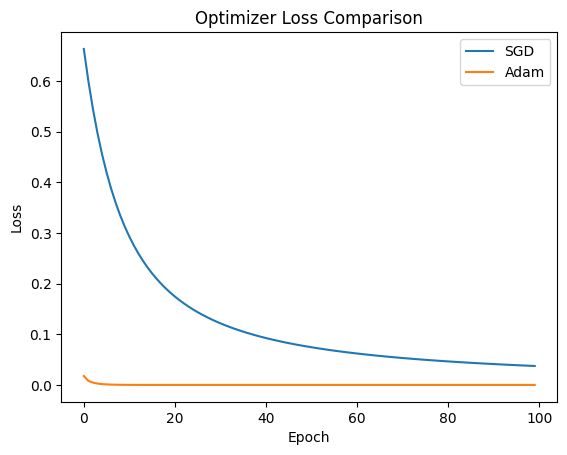

In [88]:
plt.figure()
plt.plot(train_loss_cnn,label="SGD")
plt.plot(adam_loss,label="Adam")
plt.legend()
plt.title("Optimizer Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Different optimizers adjust parameters using different update strategies.

Momentum smooths updates using past gradients,
while Adam adapts learning rates for each parameter,
often leading to faster and more stable convergence.

1.Where did training fail due to structure?

Training mainly struggled in deeper networks with sigmoid activation. As the depth increased the gradients became very small, so earlier layers stopped learning effectively and validation accuracy improved very slowly.

2.Where did optimizer matter more than activation?

The optimizer mattered more in deeper networks. With basic SGD the learning was slower and sometimes unstable, while momentum or Adam helped the model converge faster and more smoothly.

3.Where did activation matter more than depth?

Activation mattered more in deeper networks when comparing sigmoid and ReLU. ReLU allowed gradients to flow better, while sigmoid caused vanishing gradients and slower learning.

4.What causes gradient shrinkage?

Gradient shrinkage happens when gradients become very small during backpropagation. In sigmoid networks each layer multiplies the gradient by a value less than one, so after many layers the earlier layers receive almost no update.

5.Why does CNN generalize better than dense?

CNNs learn local spatial patterns using convolution filters. Because filters are shared across the image, the model captures useful features with fewer parameters. Dense networks flatten the image and lose this spatial structure.

6.Why does dropout reduce overfitting?

Dropout randomly disables some neurons during training. This prevents the network from relying too heavily on specific connections and forces the model to learn more general features.

7.When does depth hurt test performance?

Depth can hurt test performance when the network becomes too complex for the dataset. This can lead to overfitting or optimization problems, which reduces generalization on unseen data.

8.Did validation always predict test performance correctly?
Validation accuracy usually followed the same trend as test accuracy, but it was not always exact. The validation set only estimates unseen data, so small differences can occur.

MASTER TABLE


| Model | Depth | Activation | Optimizer | Parameters | Train Acc | Val Acc | Test Acc |
|------|------|------|------|------|------|------|------|
| Dense | 2-layer | sigmoid | sgd | 33 | 0.704286 | 0.748889 | 0.74 |
| Dense | 2-layer | sigmoid | momentum | 33 | 0.704286 | 0.748889 | 0.74 |
| Dense | 2-layer | relu | sgd | 33 | 0.704286 | 0.748889 | 0.74 |
| Dense | 2-layer | relu | momentum | 33 | 0.704286 | 0.748889 | 0.74 |
| Dense | 5-layer | sigmoid | sgd | 249 | 0.704286 | 0.748889 | 0.74 |
| Dense | 5-layer | sigmoid | momentum | 249 | 0.704286 | 0.748889 | 0.74 |
| Dense | 5-layer | relu | sgd | 249 | 0.704286 | 0.748889 | 0.74 |
| Dense | 5-layer | relu | momentum | 249 | 0.704286 | 0.748889 | 0.74 |
| Dense | 10-layer | sigmoid | sgd | 609 | 0.704286 | 0.748889 | 0.74 |
| Dense | 10-layer | sigmoid | momentum | 609 | 0.704286 | 0.748889 | 0.74 |
| Dense | 10-layer | relu | sgd | 609 | 0.704286 | 0.748889 | 0.74 |
| Dense | 10-layer | relu | momentum | 609 | 0.704286 | 0.748889 | 0.74 |
| CNN | - | relu | sgd | 19 | 1.00 | 1.00 | 1.00 |
| CNN | - | relu | adam | 19 | 1.00 | 1.00 | 1.00 |

ReLU networks performed better than sigmoid in deeper architectures because gradients were preserved better. Momentum and Adam optimizers improved convergence compared to basic SGD. CNN achieved the best performance because it captures spatial patterns in images more effectively than dense networks.